In [1]:
import os
from typing import List

import pandas as pd
import numpy as np
import scanpy as sc

import torch
import torch.nn as nn
from geomloss import SamplesLoss

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


from sklearn.neighbors import NearestCentroid
from sklearn.metrics import normalized_mutual_info_score as nmi



[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import cross_condition_distances
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.preprocess import (calculate_pairwise_distances, get_upper_triangle, cohen_d, 
                                 quantify_cluster_distance, embed_tf_activity)



In [3]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
model_no = 'dev'

Load data:

In [4]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
tf_labels = tf_adata.var_names
ligand_labels = ['IFNB1']

Filter expression matrix for HVGs:

In [7]:
# adata = adata[:, adata.var[adata.var['highly_variable']].index] # filter for HVGs for simplicity <-- already filtered for HVGs
# expr = sc.pp.scale(expr, copy = True)


# start dev

In [8]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,407,185,859,978,352,2215,507,258,23,115,298,300,51,6548
STIM,571,203,903,1526,462,2147,537,214,32,121,321,333,81,7451
Total,978,388,1762,2504,814,4362,1044,472,55,236,619,633,132,13999


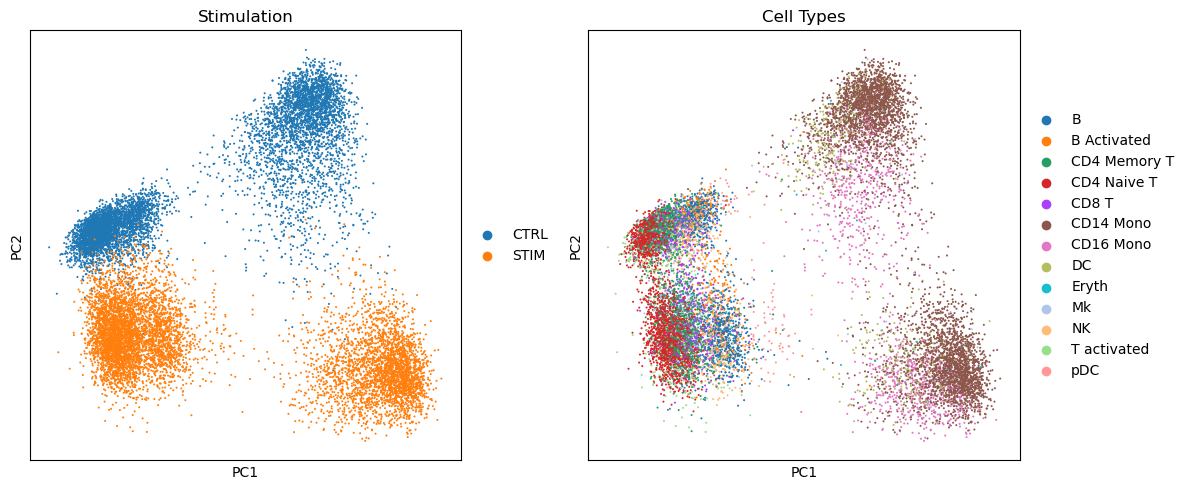

In [9]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5))

# sc.pl.umap(adata, color='leiden', ax = ax[0], show = False)
# ax[0].set_title('Clusters')
# ax[0].legend().set_visible(False)
# # ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(adata, color='stim', ax = ax[0], show = False)
ax[0].set_title('Stimulation')
# ax[1].legend().set_visible(False)

sc.pl.pca(adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
# ax[1].legend().set_visible(False)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

In [10]:
distance_df = cross_condition_distances(adata = tf_adata, 
                            column_1 = 'seurat_annotations', 
                            column_2 = 'stim', 
                            n_pcs = tf_adata.uns['pca']['pca_rank'])
distance_df.sort_values(by = 'distance', ascending = False).reset_index(drop = True)

,seurat_annotations,stim_1,stim_2,distance
0,CD14 Mono,CTRL,STIM,6.019051
1,DC,CTRL,STIM,5.435884
2,B,CTRL,STIM,5.358378
3,CD16 Mono,CTRL,STIM,4.933902
4,pDC,CTRL,STIM,4.871000
5,CD4 Naive T,CTRL,STIM,4.651253
6,NK,CTRL,STIM,4.379271
7,CD4 Memory T,CTRL,STIM,4.231110
8,Eryth,CTRL,STIM,4.192032
9,Mk,CTRL,STIM,3.934170


In [7]:
backup_tf_adata = tf_adata.copy()

In [8]:
tf_adata = backup_tf_adata.copy()

In [9]:
subset_cells = []
n_cells = 200

for ct in tf_adata.obs['seurat_annotations'].unique():
    cells = tf_adata.obs[tf_adata.obs['seurat_annotations'] == ct].index.tolist()
    if len(cells) > n_cells:
        np.random.seed(seed)
        cells = list(np.random.choice(cells, n_cells, replace = False))
    subset_cells += cells
len(subset_cells)

2387

In [10]:
tf_adata = tf_adata[subset_cells, :]
adata = adata[subset_cells, :]

n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, 4)).astype(int)[1:-1])

In [11]:
contingency_table = pd.crosstab(tf_adata.obs['stim'], tf_adata.obs['seurat_annotations'], 
                                margins=True, margins_name="Total")
contingency_table

seurat_annotations,B,B Activated,CD4 Memory T,CD4 Naive T,CD8 T,CD14 Mono,CD16 Mono,DC,Eryth,Mk,NK,T activated,pDC,Total
stim,,,,,,,,,,,,,,
CTRL,91,96,108,71,87,100,97,115,23,102,97,101,51,1139
STIM,109,104,92,129,113,100,103,85,32,98,103,99,81,1248
Total,200,200,200,200,200,200,200,200,55,200,200,200,132,2387


In [12]:
tf_adata.obs['stim'].unique()

['STIM', 'CTRL']
Categories (2, object): ['CTRL', 'STIM']

In [13]:
test_cells = tf_adata.obs[(tf_adata.obs['seurat_annotations'] == 'DC') & (tf_adata.obs['stim'] == 'STIM')].index.tolist()
train_cells = tf_adata.obs[~((tf_adata.obs['seurat_annotations'] == 'DC') & (tf_adata.obs['stim'] == 'STIM'))].index.tolist()

ligand_input = pd.DataFrame(tf_adata.obs.stim.cat.codes, columns = ['IFNB1'])
tf_output = pd.DataFrame(tf_adata.X, index = tf_adata.obs.index, columns = tf_adata.var.index)


In [14]:
me = 70
max_lr = 1e-3
lr_scaling_factor = 10
lr_period = 2

train_batch_factor = 4
test_batch_factor = 1

# initially let's discriminator learn then makes generator stronger and stronger
min_disc_penalty_weight = 0.1  # Replace with your minimum value
max_disc_penalty_weight = 5  # Replace with your maximum value
disc_penalty_step = (max_disc_penalty_weight - min_disc_penalty_weight) / (me - 1)
discriminator_penalty_weight = list(np.arange(min_disc_penalty_weight, max_disc_penalty_weight + disc_penalty_step, disc_penalty_step))

discriminator_penalty_weight = 0.001
# Create the array


In [15]:
# linear scaling of inputs/outputs
projection_amplitude_in = 1

# other parameters
bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor':50, 
                 'tolerance': 1e-5, 
                 'leak':1e-2, 
                'cat_max_norm': 1} 
vae_params = {'vae_batch_momentum': 0.01, 'vae_layer_norm': False, 'vae_dropout_rate': 0.1,
              'vae_activation_fn': nn.LeakyReLU,
              'vae_n_hidden_nodes': vae_n_hidden_nodes, 
              'vae_var_min': 1e-4}
bionet_params = {**bionet_params, **vae_params}

# training parameters
lr_params = {'max_epochs': me, 'maximum_learning_rate': max_lr, 'minimum_learning_rate': max_lr/lr_scaling_factor,
                 'lr_restart_epoch': int(me/lr_period), 'reset_optimizer_epoch': 200, 
                'lr_decay': 0.9, 'lr_restart_factor': 1, 'warmup_epochs': int(me/10)}

other_params = {'train_batch_size': round(len(train_cells)/train_batch_factor), 
                'test_batch_size': round(len(test_cells)/test_batch_factor), 'validation_batch_size': np.nan, 
                    'network_noise_scale': 10, 'gradient_noise_scale': 1e-9}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 50, 
                          'subset_n_spectral': 10}
target_spectral_radius = 0.8

In [16]:
projection_amplitude_out = 1

In [17]:
regularization_params = {'input_lambda_L2': 0, 
                         'bn_weights_lambda_l2': 0, 
                         'bn_bias_lambda_L2': 0, # 5e-8
                         'output_weights_lambda_L2': 0,
                         'output_bias_lambda_L2': 0,
                         'moa_lambda_L1': 0,  
                         'uniform_lambda_L2': 0,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 0, 
                        'vae_scaling_KL': 1e-2}


discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': [768, 512, 256],
 'maximum_learning_rate': max_lr,
 'minimum_learning_rate':max_lr/lr_scaling_factor,
 'lr_restart_epoch': int(me/lr_period),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 0,
                        'discriminator_penalty_weight': discriminator_penalty_weight}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}

In [18]:
regularization_params = {'input_lambda_L2': 1e-7, 
                         'bn_weights_lambda_l2': 1e-7, 
                         'bn_bias_lambda_L2': 0, # 5e-8
                         'output_weights_lambda_L2': 1e-7,
                         'output_bias_lambda_L2': 1e-7,
                         'moa_lambda_L1': 1e-6,  
                         'uniform_lambda_L2': 1e-8,#, 1e-5,
                         'uniform_min': 0,
                         'uniform_max': 1, 
                         'spectral_loss_factor': 1e-6,
                        'vae_lambda_l2': 0, 
                        'vae_scaling_KL': 1e-1}


discriminator_params = {'batch_momentum': 0.01,
 'layer_norm': False,
 'dropout_rate': 0.1,
 'activation_fn': nn.LeakyReLU,
 'n_hidden_nodes': [768, 512, 256],
 'maximum_learning_rate': max_lr,
 'minimum_learning_rate':max_lr/lr_scaling_factor,
 'lr_restart_epoch': int(me/lr_period),
 'reset_optimizer_epoch': 200,
 'lr_decay': 0.9,
 'lr_restart_factor': 1,
 'warmup_epochs': int(me/10),
 'optimizer': torch.optim.Adam,
 'discriminator_lambda_L2': 0,
                        'discriminator_penalty_weight': discriminator_penalty_weight}
training_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params}

In [19]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     expr = adata.to_df(), 
                     covariates = tf_adata.obs,
                     categorical_covariate_keys = ['seurat_annotations'],
                     projection_amplitude_in = projection_amplitude_in, 
                     projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)


In [20]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# training loop
trainer = TrainSC(mod = mod,
                   prediction_optimizer = torch.optim.Adam,
                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = discriminator_params,
                   hyper_params = training_params,
                   train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
                   train_seed = seed, 
                   track_test = False,
                   track_validation = False)

In [21]:
mod = trainer.train_model(verbose = True)

torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))
io.write_pickled_object(trainer,  os.path.join(models_path, 'trainer_' + str(model_no) + '.pickle'))

  1%|▋                                                  | 1/70 [00:02<02:42,  2.35s/it]

i=0, l(tr)=91.98118, s=0.23169, r=0.00010, v=0.00000


100%|██████████████████████████████████████████████████| 70/70 [02:14<00:00,  1.92s/it]


Training ran in: 2 min 14.52 sec


In [22]:
train_stats_df = trainer.stats['train'].copy()
# test_stats_df = trainer.stats['test'].copy()

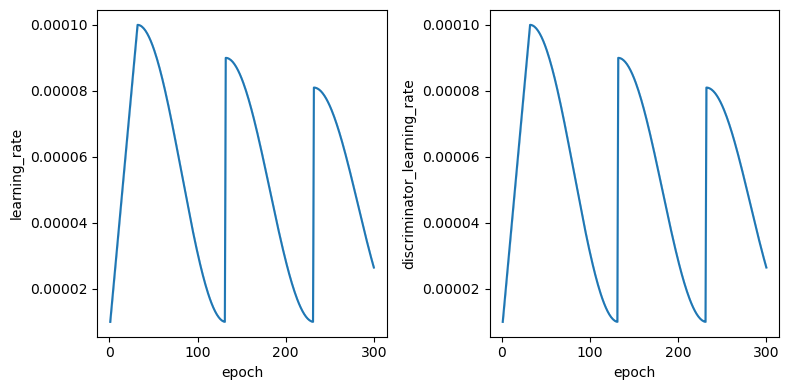

In [129]:
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
fig.tight_layout()

/tmp/ipykernel_260682/3261138777.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()
/tmp/ipykernel_260682/3261138777.py:46: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
/tmp/ipykernel_260682/3261138777.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
/tmp/ipykernel_260682/3261138777.py:71: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', 

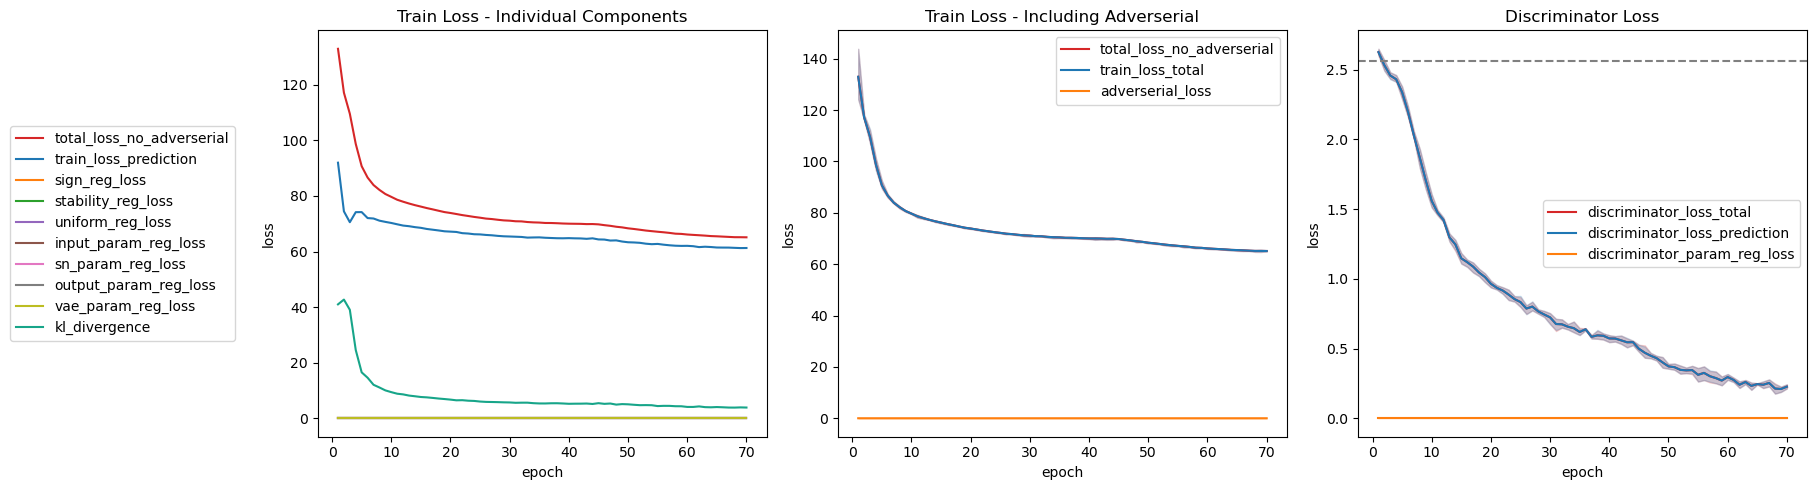

In [23]:
# font_scaling_factor = 1.2
# with plt.rc_context({
#     'font.size': plt.rcParams['font.size'] * font_scaling_factor,
#     'axes.titlesize': plt.rcParams['axes.titlesize'] * font_scaling_factor,
#     'axes.labelsize': plt.rcParams['axes.labelsize'] * font_scaling_factor,
#     'xtick.labelsize': plt.rcParams['xtick.labelsize'] * font_scaling_factor,
#     'ytick.labelsize': plt.rcParams['ytick.labelsize'] * font_scaling_factor,
#     'legend.fontsize': plt.rcParams['legend.fontsize'] * font_scaling_factor
# }):


fig, ax = plt.subplots(ncols = 3, figsize = (18,5))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

# TODO: delete this next line
viz_df = viz_df.groupby(['epoch', 'loss_type']).mean().reset_index()

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[0])
# ax[0].set_yscale('log')
ax[0].legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax[0].set_title('Train Loss - Individual Components')
# ax[0].set_yscale('log')


loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']
viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[1].set_title('Train Loss - Including Adverserial')


loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']
viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')


# ax[0].set_yscale('log')
ax[2].legend(loc='best')#, bbox_to_anchor=(-0.7, 0.5))
ax[2].set_title('Discriminator Loss')

fig.tight_layout()


The initial drop in the discriminator mens that it learned, then as the adverserial penalty became stronger, the generator made the discriminator go back to the gray line (random). 

While all predictions are OOD, we can also run predictions on any of the seen OR unseen inputs, since the model asks a counterfactual. Thus, we can ask how well it can alter the output features (TF activity) of input seen data (gene expression) to unseen conditions, and even how well it can alter output features of unseen input data.  

In [24]:
md_pred = tf_adata.obs.copy()

# for future changes, include these checks
if trainer.X_test.shape[0] + trainer.X_train.shape[0] != md_pred.shape[0]:
    raise ValueError('Unexpected cells have not been accounted for')
    
test_md = tf_adata.obs.loc[trainer.X_test.index, :].copy()
test_md['condition'] = test_md.stim.astype(str) + '_' + test_md.seurat_annotations.astype(str)
if test_md.condition.nunique() != 1:
    raise ValueError('Expected only one condition to be tested at a time')

# actual values
md_pred.insert(loc = 0, column = 'cell_id', value = md_pred.index)
md_pred['value_type'] = 'actual' # actual vs predicted

md_pred['input_data_type'] = 'seen' # counterfactuals
md_pred.loc[trainer.X_test.index, 'input_data_type'] = 'unseen' # completely unseen inputs

md_pred['counter_factual'] = ''

# predicted values
_md_pred = md_pred.copy()
_md_pred['value_type'] = 'predicted'
_md_pred['counter_factual'] = test_md.condition.unique().tolist()[0]

# merge and format
md_pred = pd.concat([md_pred, _md_pred], axis = 0)
md_pred['value_type'] = pd.Categorical(md_pred['value_type'], 
                                       categories=['actual', 'predicted'], ordered=True)
md_pred['input_data_type'] = pd.Categorical(md_pred['input_data_type'], 
                                       categories=['seen', 'unseen'], ordered=True)
md_pred['counter_factual'] = pd.Categorical(md_pred['counter_factual'], 
                                       categories=['STIM_DC', ''], ordered=True)
md_pred['condition'] = md_pred.stim.astype(str) + '^' + md_pred.seurat_annotations.astype(str)
md_pred.reset_index(inplace = True, drop = True)


Prepare the inputs:

In [25]:
# # inputs
# X_test = mod.df_to_tensor(trainer.X_test)
# y_test = mod.df_to_tensor(trainer.y_test)
# expr_test = mod.df_to_tensor(mod.expr.loc[trainer.X_test.index, :])
# covariates_idx_test = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_test.index)

y_test_df = tf_adata.to_df()
y_test = mod.df_to_tensor(y_test_df)

X_test = pd.DataFrame(tf_adata.obs.stim)
X_test.rename(columns = {'stim': 'IFNB1'}, inplace = True)
X_test.IFNB1 = X_test.IFNB1.map({'STIM': 1, 'CTRL': 0})
X_test = mod.df_to_tensor(X_test)

expr_test = mod.df_to_tensor(mod.expr.loc[tf_adata.obs.index, :])

cat_cov = mod.signaling_network.covariates[mod.signaling_network.covariates.seurat_annotations.isin(test_md.seurat_annotations.unique())].index.tolist()
if mod.signaling_network.covariates_idx.loc[cat_cov, 'seurat_annotations'].nunique() != 1:
    raise ValueError("Haven't generalized to multiple predictions")
cat_cov_idx = mod.signaling_network.covariates_idx.loc[cat_cov, 'seurat_annotations'].unique().tolist()
covariates_idx_test = torch.tensor(cat_cov_idx*tf_adata.obs.shape[0], device = mod.device, dtype = torch.int64).view(-1,1)



Run the prediction:

In [26]:
mod.eval()
with torch.inference_mode():
    y_predicted, Y_full, biases = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
    bias_global, bias_mu, bias_log_sigma_squared = biases

    
# # formatting
y_predicted = pd.DataFrame(y_predicted.cpu().detach().numpy(), columns = y_test_df.columns, index = y_test_df.index)
bias_global = pd.DataFrame(bias_global.detach().cpu().numpy(), index = tf_adata.obs.index)
bias_global.columns = bias_global.columns.map({v: k for k,v in mod.node_idx_map.items()})
tf_adata_pred = sc.AnnData(X = pd.concat([y_test_df, y_predicted], axis = 0).reset_index(drop = True), obs=md_pred)


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Assessment 1: The bias is context-independent:

To do here: add what the bias looks like when teh same model is run with a very low discriminator penalty weight (essentially eliminating bias).

In [27]:
bias_adata = sc.AnnData(X = bias_global, obs = tf_adata.obs)
embed_tf_activity(bias_adata, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

# # categorical embedding
# embedding_adata = mod.signaling_network.cat_embeddings['seurat_annotations']._parameters['weight'].detach().cpu().numpy()
# embedding_adata = pd.DataFrame(embedding_adata)
# embedding_adata.columns = embedding_adata.columns.map({v: k for k,v in mod.node_idx_map.items()})
# md_emb = pd.DataFrame(index = embedding_adata.index, columns = ['seurat_annotations'])
# md_emb['seurat_annotations'] = md_emb.index.map(dict(zip(mod.signaling_network.covariates_idx.seurat_annotations, 
#          mod.signaling_network.covariates.seurat_annotations)))
# md_emb['seurat_annotations'] = pd.Categorical(md_emb['seurat_annotations'], 
#                                        categories=tf_adata.obs.seurat_annotations.cat.categories.tolist())
# embedding_adata = sc.AnnData(X = embedding_adata, obs = md_emb)
# embed_tf_activity(embedding_adata, scanpy_pca = False, cluster_col_name = 'leiden', 
#                  n_components = min(embedding_adata.shape))


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:282: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata, resolution = resolution) # cluster


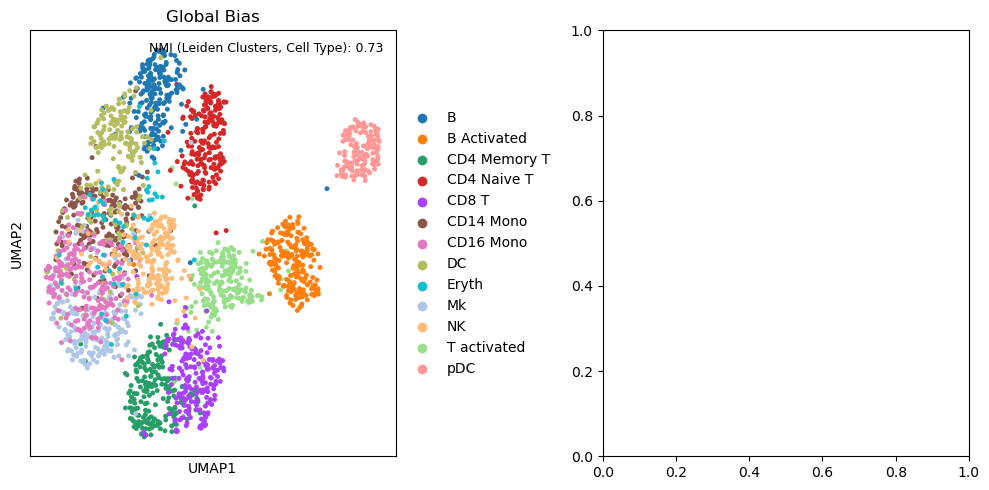

In [28]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))

sc.pl.umap(bias_adata, color='seurat_annotations', ax = ax[0], show = False)
ax[0].set_title('Global Bias')
# ax[0].legend().set_visible(False)

bias_nmi = nmi(bias_adata.obs.leiden, bias_adata.obs.seurat_annotations)
ax[0].annotate('NMI (Leiden Clusters, Cell Type): {:.2f}'.format(bias_nmi),
                xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)

# sc.pl.umap(embedding_adata,  color='seurat_annotations', ax = ax[1], show = False,  size=100)
# ax[1].set_title('Categorical Embedding')

fig.tight_layout()
plt.show()

Embed the predictions and actual values together, using the resolution and rank parameters identified from the actual values in Notebook 03:

In [29]:
embed_tf_activity(tf_adata = tf_adata_pred, 
                 scanpy_pca = False, 
                 cluster_col_name = 'TF_clusters_predicted', 
                 n_components = 50, 
                  pc_rank = tf_adata.uns['pca']['pca_rank'], 
                 resolution =  tf_adata.uns['leiden']['params']['resolution'])

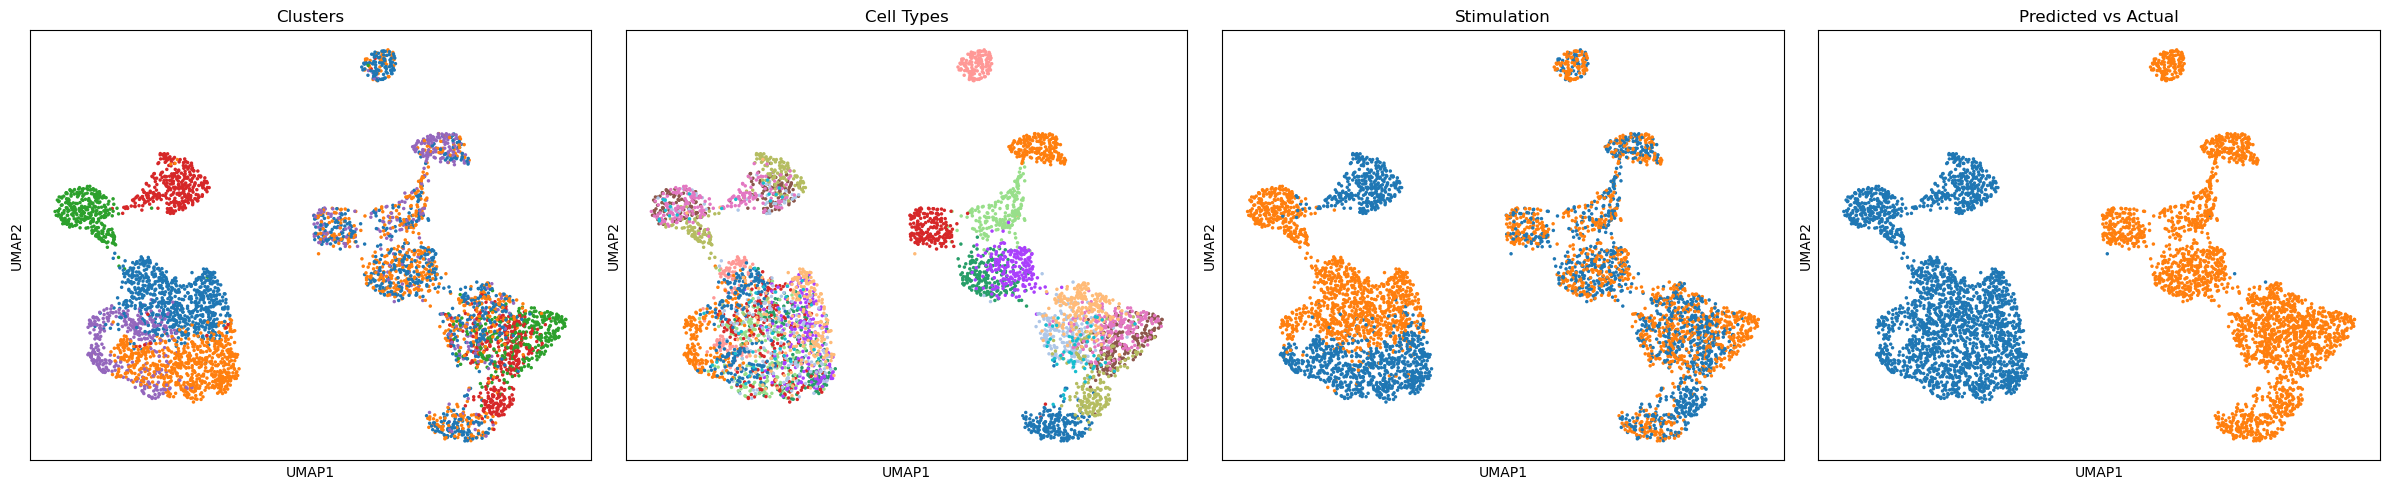

In [30]:
fig, ax = plt.subplots(ncols = 4, figsize = (24, 5))

sc.pl.umap(tf_adata_pred, color='TF_clusters', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.umap(tf_adata_pred, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.umap(tf_adata_pred, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_tf_adata_pred.obs.TF_clusters, tf_tf_adata_pred.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)


sc.pl.umap(tf_adata_pred, color='value_type', ax = ax[3], show = False)
ax[3].set_title('Predicted vs Actual')
ax[3].legend().set_visible(False)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


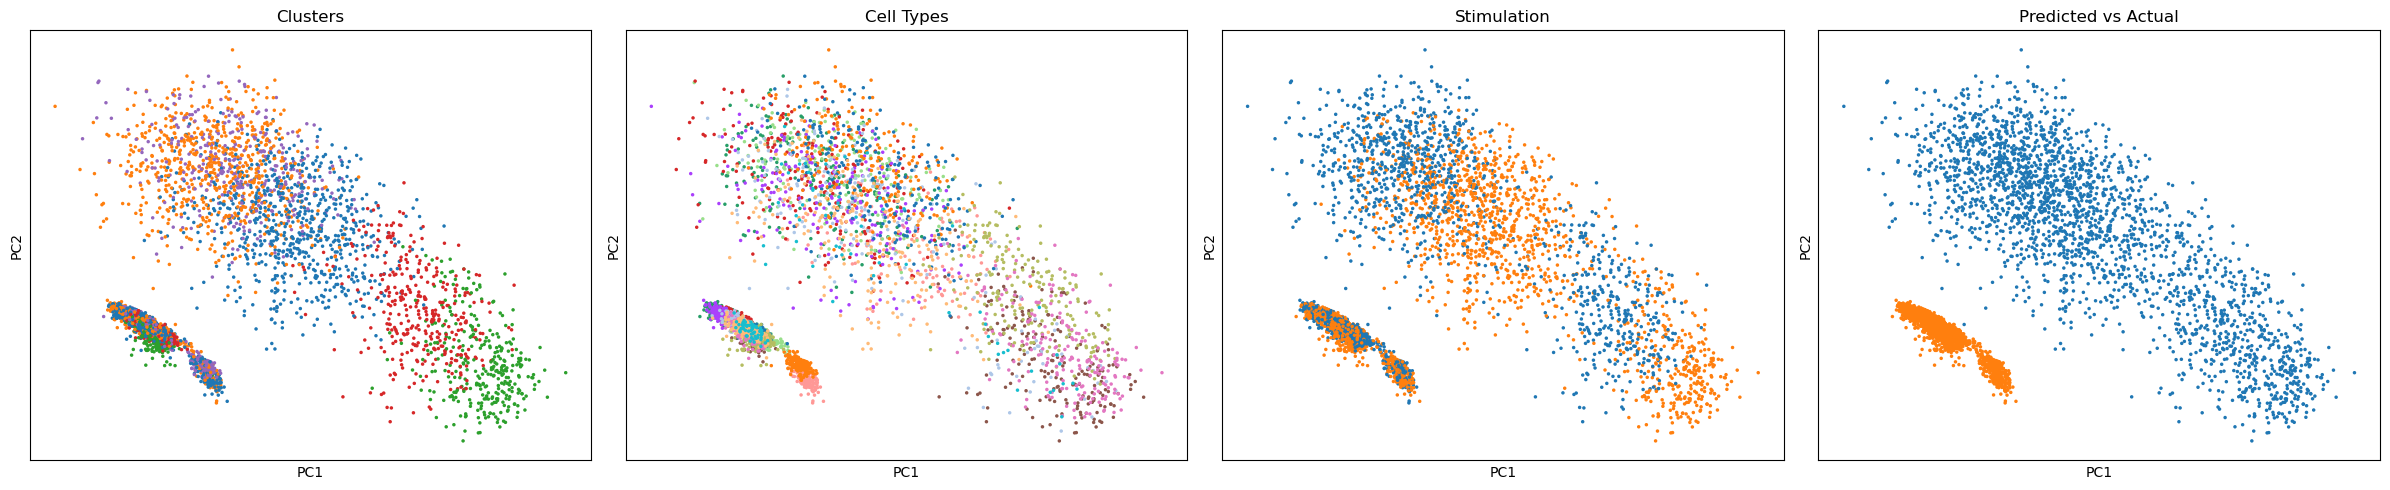

In [31]:
fig, ax = plt.subplots(ncols = 4, figsize = (24, 5))

sc.pl.pca(tf_adata_pred, color='TF_clusters', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(tf_adata_pred, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.pca(tf_adata_pred, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_tf_adata_pred.obs.TF_clusters, tf_tf_adata_pred.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)


sc.pl.pca(tf_adata_pred, color='value_type', ax = ax[3], show = False)
ax[3].set_title('Predicted vs Actual')
ax[3].legend().set_visible(False)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
# the comparisons we want to make
cell_map = {'all': tf_adata_pred.obs.cell_id.unique().tolist(), 
           'OOD': tf_adata_pred.obs[tf_adata_pred.obs.input_data_type == 'unseen'].cell_id.unique().tolist(), 
           'in distribution': tf_adata_pred.obs[tf_adata_pred.obs.counter_factual == 'seen'].cell_id.unique().tolist(), 
           'stimulated': tf_adata_pred.obs[tf_adata_pred.obs.stim == 'STIM'].cell_id.unique().tolist(), 
           'unstimulated': tf_adata_pred.obs[tf_adata_pred.obs.stim == 'CTRL'].cell_id.unique().tolist(), 
           'cell_type': {ct: tf_adata_pred.obs[tf_adata_pred.obs.seurat_annotations == ct].cell_id.unique().tolist() 
                         for ct in tf_adata_pred.obs.seurat_annotations.unique()}, 
           'condition': {cond: tf_adata_pred.obs[tf_adata_pred.obs.condition == cond].cell_id.unique().tolist() 
                         for cond in tf_adata_pred.obs.condition.unique()}}



In [65]:
n_perm = 10

In [54]:
ct = 'pDC'

,cell_id,orig.ident,nCount_RNA,nFeature_RNA,stim,seurat_annotations,n_genes,gene_clusters,TF_clusters,value_type,input_data_type,counter_factual
200,AAACATACCTGGTA.1,IMMUNE_CTRL,3156,1109,CTRL,pDC,1109,7,6,actual,seen,
201,AACAAACTTGATGC.1,IMMUNE_CTRL,2811,1216,CTRL,pDC,1216,19,4,actual,seen,
202,AAGATGGATCTTTG.1,IMMUNE_CTRL,2443,1117,CTRL,pDC,1117,7,4,actual,seen,
203,AATGTCCTATCGGT.1,IMMUNE_CTRL,3046,1219,CTRL,pDC,1219,19,4,actual,seen,
204,AATTACGAACCTTT.1,IMMUNE_CTRL,2417,1014,CTRL,pDC,1014,7,4,actual,seen,
...,...,...,...,...,...,...,...,...,...,...,...,...
2714,TCAGGATGACCATG.1,IMMUNE_STIM,2306,740,STIM,pDC,740,27,6,predicted,seen,STIM_DC
2715,TCTAACACTCGCTC.1,IMMUNE_STIM,1594,781,STIM,pDC,781,26,10,predicted,seen,STIM_DC
2716,TCTGATACCCGAAT.1,IMMUNE_STIM,1809,772,STIM,pDC,772,27,6,predicted,seen,STIM_DC
2717,TGAATAACAGGCGA.1,IMMUNE_STIM,3145,1239,STIM,pDC,1239,27,6,predicted,seen,STIM_DC


In [50]:
tf_adata_pred.obs[tf_adata_pred.obs.stim == 'CTRL'].cell_id.unique().tolist()

['ATATGAACCTACCC.1',
 'ATACCACTTCCAGA.1',
 'CGCACTTGTCAGTG.1',
 'CCCTTACTGGTTCA.1',
 'ATTACCACGGAGGT.1',
 'CAAGTTCTTTCCAT.1',
 'TAAAGACTTGGAAA.1',
 'AAGCCAACTGACCA.1',
 'CTCGAGCTTTGTCT.1',
 'TTAGCTACTGGTTG.1',
 'TATCACTGTCAGTG.1',
 'TACTCTGACGTACA.1',
 'TGCTATACATTGGC.1',
 'ATCCAGGAGCATCA.1',
 'GCATGATGAGGGTG.1',
 'AGTGACACAAAGTG.1',
 'ATCTCAACCGTGAT.1',
 'ATGTCGGACTTACT.1',
 'AGGTGTTGGTTTGG.1',
 'TGCACAGATAGCGT.1',
 'CGAGATTGACACGT.1',
 'ACGAGGGAGAATCC.1',
 'TACCATTGCAGATC.1',
 'ACTCGCACGTAAAG.1',
 'CTACGCACCCCACT.1',
 'TGTTACACTCTTCA.1',
 'CATGAGACCACTTT.1',
 'GAGTCTGAAGAAGT.1',
 'AGGATAGATCCCGT.11',
 'GAGGGATGTGCCAA.1',
 'AGCCGGTGACGTGT.1',
 'TGGAACTGGCCATA.1',
 'GACAACTGCCATAG.1',
 'ATTCTTCTCGAGAG.1',
 'TGCTATACTCAGGT.1',
 'GAATGGCTTCTCCG.1',
 'CATGCCACCAGAAA.1',
 'TACGCCACCGTAAC.1',
 'GTACAGTGACACGT.1',
 'TAAGGCTGCCCTCA.1',
 'CAACCAGAGTATCG.1',
 'CCATCCGACACTAG.1',
 'TTAGTCTGCTGTTT.1',
 'AACGTGTGTGAGGG.1',
 'GAAGGTCTATCGTG.1',
 'TATAGCCTGACGTT.1',
 'TTACACACGTAGCT.1',
 'TCACGAGAGG

In [43]:
tf_adata_pred.obs.head()

,cell_id,orig.ident,nCount_RNA,nFeature_RNA,stim,seurat_annotations,n_genes,gene_clusters,TF_clusters,value_type,input_data_type,counter_factual
0,CACGAAACGAAGGC.1,IMMUNE_STIM,3324,918,STIM,CD14 Mono,918,33,2,actual,seen,
1,TGTGGATGTCTTTG.1,IMMUNE_STIM,3604,831,STIM,CD14 Mono,831,45,2,actual,seen,
2,ACGACCCTGGTGGA.1,IMMUNE_CTRL,4620,1170,CTRL,CD14 Mono,1170,6,7,actual,seen,
3,CTCCTACTAGTAGA.1,IMMUNE_CTRL,2546,826,CTRL,CD14 Mono,826,2,16,actual,seen,
4,AGTCGAACGGGTGA.1,IMMUNE_STIM,3132,699,STIM,CD14 Mono,699,38,2,actual,seen,


,cell_id,orig.ident,nCount_RNA,nFeature_RNA,stim,seurat_annotations,n_genes,gene_clusters,TF_clusters,value_type,input_data_type,counterfactual,counter_factual
0,CACGAAACGAAGGC.1,IMMUNE_STIM,3324,918,STIM,CD14 Mono,918,33,2,actual,seen,,NaN
1,TGTGGATGTCTTTG.1,IMMUNE_STIM,3604,831,STIM,CD14 Mono,831,45,2,actual,seen,,NaN
2,ACGACCCTGGTGGA.1,IMMUNE_CTRL,4620,1170,CTRL,CD14 Mono,1170,6,7,actual,seen,,NaN
3,CTCCTACTAGTAGA.1,IMMUNE_CTRL,2546,826,CTRL,CD14 Mono,826,2,16,actual,seen,,NaN
4,AGTCGAACGGGTGA.1,IMMUNE_STIM,3132,699,STIM,CD14 Mono,699,38,2,actual,seen,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2382,TCCCGAACTTCGTT.1,IMMUNE_STIM,4222,702,STIM,Eryth,702,45,0,actual,seen,,NaN
2383,TCGGACCTATCAGC.1,IMMUNE_STIM,2050,502,STIM,Eryth,502,26,6,actual,seen,,NaN
2384,TGACGCCTCTTGTT.1,IMMUNE_STIM,7168,899,STIM,Eryth,899,30,0,actual,seen,,NaN
2385,TGGTCAGACAAGCT.1,IMMUNE_STIM,4225,550,STIM,Eryth,550,22,11,actual,seen,,NaN


In [8]:
primary_comparison = calculate_pairwise_distances(y_predicted, 
                                                  trainer.y_test, 
                                                  distance_metric = 'euclidean',
                                                  invert_corr = True,
                                                  axis = 0).values.flatten()
# ---------------------------------
experimental_comparison = get_upper_triangle(calculate_pairwise_distances(trainer.y_test, 
                                                  distance_metric = 'euclidean',
                                                  invert_corr = True,
                                                  axis = 0))

# ------------baseline 1: within vs across perturbation distance------------
md_ = tf_adata.obs[tf_adata.obs.seurat_annotations == ct]
# filter to cell of interest
ctrl_cells = md_[md_.stim == 'STIM'].index.tolist()
stim_cells = md_[md_.stim == 'CTRL'].index.tolist()

ctrl_X = tf_adata[ctrl_cells, :].to_df()
stim_X = tf_adata[stim_cells, :].to_df()
# get pairwise distances
baseline_1 = calculate_pairwise_distances(df1 = ctrl_X,
                                        df2 = stim_X,
                                        distance_metric = 'euclidean',
                                        axis = 0, # compare the cells
                                       ).values.flatten()

# ------------baseline 2: distance to random------------
# TODO: modify the label and comparison_combination_subsets if have multiple cell types in on
md = tf_adata[trainer.y_test.index, :].obs.copy()
md = pd.concat([md, md])
md['prediction'] = ['actual']*trainer.y_test.shape[0] + ['predicted']*y_predicted.shape[0]
md['prediction'] = md['prediction'].astype(str)
tf_adata_b2 = sc.AnnData(X = pd.concat([trainer.y_test, y_predicted]), obs = md)

baseline_2 = quantify_cluster_distance(tf_adata = tf_adata_b2,
                          label = 'prediction', 
                              comparison_combination_subset = None,
                              comparison_subset = None,
                              label_subset = None,
                              include_self = False, 
                              feature_subset = None,
                              distance_metric = 'euclidean',
                              normal = True, 
                              use_pcs = False,
                              rank = None, 
                              n_perm = n_perm, 
                              alternative = 'less', 
                              seed = 888, 
                             n_cores = 1)

baseline_2_emd = quantify_emd(tf_adata = tf_adata_b2, 
                              label = 'prediction', 
                              comparison_combination_subset = None,
                              comparison_subset = None, 
                              label_subset = None,
                              include_self = False,
                              feature_subset = None,
                              use_pcs = False, 
                              rank = None, 
                              n_perm = n_perm, 
                              alternative = 'less', 
                              seed = 888,
                              n_cores = 1,
                              device = device, 
                              emd_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(default_device))

# ------------baseline 3: random model------------

# you are here:
- visualization
- difference in differences (cohen's d comparisons)

In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_train, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots()
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')

# sns.histplot(spearmans, ax = ax)
;

In [ ]:
pca_mod = tf_adata.uns['pca']['pca_mod']
rank = tf_adata.uns["pca"]['pca_rank']


md = tf_adata.obs
md['condition'] = tf_adata.obs['seurat_annotations'].astype(str) + '^' + tf_adata.obs['stim'].astype(str)

X_pca = pd.DataFrame(tf_adata.obsm['X_pca'][:, :rank], 
                 index = tf_adata.obs.index, 
                columns = ['PC_{}'.format(i + 1) for i in range(rank)])
clf = NearestCentroid()
clf.fit(X_pca, md['condition'])
X_pca_centroids = pd.DataFrame(clf.centroids_, columns = clf.feature_names_in_, index = clf.classes_)

In [ ]:
viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_train.index, :], pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_train.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()



In [ ]:
# inputs
X_test = mod.df_to_tensor(trainer.X_test)
y_test = mod.df_to_tensor(trainer.y_test)
expr_test = mod.df_to_tensor(mod.expr.loc[trainer.X_test.index, :])
covariates_idx_test = mod.signaling_network.covariates_to_tensor(sample_ids = trainer.X_test.index)

# run prediction
mod.eval()
with torch.inference_mode():
    Y_hat, Y_full, biases = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
    bias_global, bias_mu, bias_log_sigma_squared = biases

# formatting
y_predicted = pd.DataFrame(Y_hat.cpu().detach().numpy())
y_predicted.index, y_predicted.columns = trainer.y_test.index, trainer.y_test.columns

In [ ]:
pearsons = trainer.get_pearson_correlation(Y_hat, y_test, axis=1, return_mean=False)

In [ ]:
fig, ax = plt.subplots(figsize = (4,3))
sns.histplot(pearsons, ax = ax)
ax.set_xlabel('Feature-wise TF activity Pearons: predicted vs actual')
;

In [ ]:
fig, ax = plt.subplots(figsize = (10,5), ncols = 2)


viz_df = pd.concat([X_pca.loc[trainer.y_test.index, :], pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[0])
ax[0].set_title('Actual Values')
ax[0].legend().set_visible(False)



y_pred_pca = pd.DataFrame(pca_mod.transform(y_predicted), index = y_predicted.index, 
                          columns = ['PC_{}'.format(i + 1) for i in range(pca_mod.n_components)]).iloc[:, :rank]
viz_df = pd.concat([y_pred_pca, pd.DataFrame(md.loc[trainer.y_test.index, 'condition'])], 
                  axis = 1)
sns.scatterplot(data = viz_df,x = 'PC_1', y = 'PC_2', hue = 'condition', ax = ax[1])
ax[1].set_title('Predicted Values')
ax[1].legend().set_visible(False)

fig.tight_layout()